In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
pip install nibabel torchio


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 19.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjit

In [2]:
import pandas as pd

# Đọc participants.xlsx và tạo age_labels.csv
df = pd.read_excel("/kaggle/input/processed-brain-data/data_processed/participants.xlsx")
df[["subject_id", "subject_age"]].rename(columns={"subject_age": "age"}).to_csv("age_labels.csv", index=False)


In [3]:
import os
import glob
import torch
import nibabel as nib
import pandas as pd
from torch.utils.data import Dataset, DataLoader

class KaggleBrainMRIDataset(Dataset):
    def __init__(self, root_dir, label_csv, transform=None):
        self.transform = transform
        self.samples = []

        df = pd.read_csv(label_csv)
        self.age_map = dict(zip(df['subject_id'], df['age']))

        pattern = os.path.join(root_dir, "sub-*/anat/*.nii*")
        nii_paths = glob.glob(pattern)

        for path in nii_paths:
            fname = os.path.basename(path)
            subject_id = fname.split('_')[0]
            if subject_id in self.age_map:
                age = self.age_map[subject_id]
                self.samples.append((path, age))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, age = self.samples[idx]
        nii = nib.load(path)
        image = torch.from_numpy(nii.get_fdata().astype('float32')).unsqueeze(0)
        image = (image - image.min()) / (image.max() - image.min() + 1e-5)

        if self.transform:
            image = self.transform(image)

        age_tensor = torch.tensor([age / 100.0], dtype=torch.float32)
        return image, age_tensor

def get_kaggle_loader(root_dir, label_csv="age_labels.csv", batch_size=2, shuffle=True):
    dataset = KaggleBrainMRIDataset(root_dir, label_csv)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


In [4]:
loader = get_kaggle_loader(
    root_dir="/kaggle/input/processed-brain-data/data_processed",
    label_csv="age_labels.csv",
    batch_size=2
)

for imgs, ages in loader:
    print("Ảnh MRI shape:", imgs.shape)  # (B, 1, D, H, W)
    print("Tuổi:", ages)                # (B, 1)
    break


Ảnh MRI shape: torch.Size([2, 1, 130, 130, 130])
Tuổi: tensor([[0.1900],
        [0.2900]])


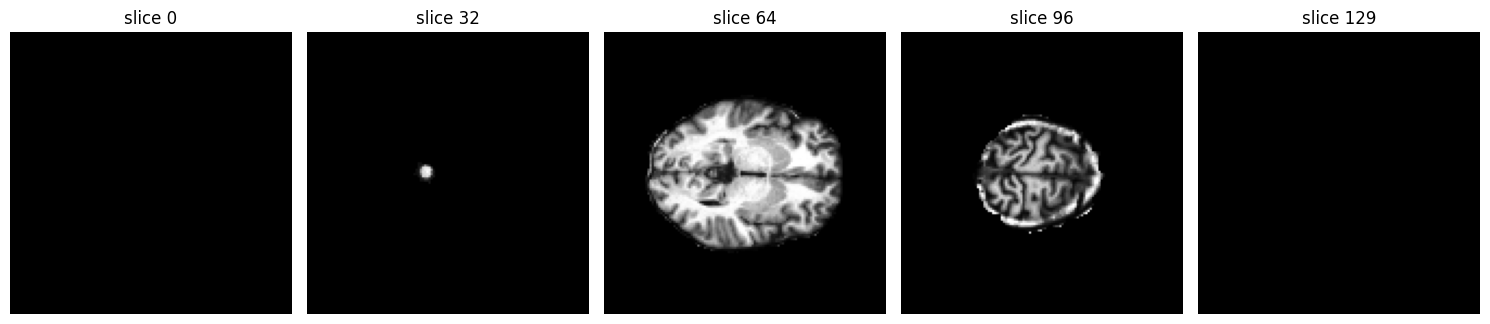

In [5]:
import matplotlib.pyplot as plt

def show_slices(tensor, axis=2, num_slices=5):
    volume = tensor.squeeze().numpy()
    slice_indices = torch.linspace(0, volume.shape[axis]-1, steps=num_slices).int()
    fig, axs = plt.subplots(1, num_slices, figsize=(15, 4))
    for i, idx in enumerate(slice_indices):
        img = volume[idx] if axis == 0 else volume[:, idx] if axis == 1 else volume[:, :, idx]
        axs[i].imshow(img, cmap="gray")
        axs[i].axis('off')
        axs[i].set_title(f"slice {idx.item()}")
    plt.tight_layout()
    plt.show()

show_slices(imgs[0])


### Generator


In [8]:
import torch
import torch.nn as nn

class Generator3D(nn.Module):
    def __init__(self, z_dim=100, age_dim=1, output_shape=(1, 64, 64, 64)):
        super().__init__()
        self.input_dim = z_dim + age_dim
        self.init_dim = 512
        self.fc = nn.Linear(self.input_dim, self.init_dim * 4 * 4 * 4)

        self.deconv = nn.Sequential(
            nn.BatchNorm3d(self.init_dim),
            nn.ReLU(),
            nn.ConvTranspose3d(self.init_dim, 256, 4, stride=2, padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(),
            nn.ConvTranspose3d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.ConvTranspose3d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.ConvTranspose3d(64, 1, 4, stride=2, padding=1),
            nn.Tanh()
        )

        self.output_shape = output_shape

    def forward(self, z, age):
        x = torch.cat([z, age], dim=1)
        x = self.fc(x).view(-1, self.init_dim, 4, 4, 4)
        x = self.deconv(x)
        return x  # Output shape: (B, 1, 64, 64, 64)


### Discriminator


In [9]:
import torch
import torch.nn as nn

class Discriminator3D(nn.Module):
    def __init__(self, input_shape=(1, 64, 64, 64)):
        super().__init__()

        channels, D, H, W = input_shape

        self.model = nn.Sequential(
            nn.Conv3d(channels, 64, kernel_size=4, stride=2, padding=1),  # -> (64, 32, 32, 32)
            nn.LeakyReLU(0.2),
            nn.Conv3d(64, 128, kernel_size=4, stride=2, padding=1),       # -> (128, 16, 16, 16)
            nn.BatchNorm3d(128),
            nn.LeakyReLU(0.2),
            nn.Conv3d(128, 256, kernel_size=4, stride=2, padding=1),      # -> (256, 8, 8, 8)
            nn.BatchNorm3d(256),
            nn.LeakyReLU(0.2),
            nn.Conv3d(256, 512, kernel_size=4, stride=2, padding=1),      # -> (512, 4, 4, 4)
            nn.BatchNorm3d(512),
            nn.LeakyReLU(0.2),
            nn.Flatten(),                                                 # -> (B, 512*4*4*4)
            nn.Linear(512 * 4 * 4 * 4, 1),
            nn.Sigmoid()  # đầu ra xác suất ảnh real/fake
        )

    def forward(self, x):
        return self.model(x)


### Regress


In [11]:
import torch
import torch.nn as nn

class TaskBranch3D(nn.Module):
    def __init__(self, input_shape=(1, 64, 64, 64)):
        super().__init__()

        channels, D, H, W = input_shape

        self.model = nn.Sequential(
            nn.Conv3d(channels, 32, kernel_size=4, stride=2, padding=1),  # -> (32, 32, 32, 32)
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.Conv3d(32, 64, kernel_size=4, stride=2, padding=1),        # -> (64, 16, 16, 16)
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.Conv3d(64, 128, kernel_size=4, stride=2, padding=1),       # -> (128, 8, 8, 8)
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.Conv3d(128, 256, kernel_size=4, stride=2, padding=1),      # -> (256, 4, 4, 4)
            nn.BatchNorm3d(256),
            nn.ReLU(),
            nn.Flatten(),                                                 # -> (B, 256*4*4*4)
            nn.Linear(256 * 4 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 1)  # Dự đoán tuổi (regression)
        )

    def forward(self, x):
        return self.model(x)  # output: (B, 1)


### Loss function


In [12]:
import torch
import torch.nn as nn

bce_loss = nn.BCELoss()
mse_loss = nn.MSELoss()

def discriminator_loss(d_real, d_fake):
    """
    d_real: đầu ra D cho ảnh thật
    d_fake: đầu ra D cho ảnh giả
    """
    real_labels = torch.ones_like(d_real)
    fake_labels = torch.zeros_like(d_fake)
    loss_real = bce_loss(d_real, real_labels)
    loss_fake = bce_loss(d_fake, fake_labels)
    return loss_real + loss_fake

def generator_loss(d_fake):
    """
    Generator muốn D đánh giá ảnh giả là thật
    """
    real_labels = torch.ones_like(d_fake)
    return bce_loss(d_fake, real_labels)

def task_guided_loss(predicted_age, target_age):
    """
    Regression loss: tuổi dự đoán từ ảnh giả và tuổi thật
    """
    return mse_loss(predicted_age, target_age)


In [ ]:
import torch
import torch.nn as nn

# ------------------------
# ✅ Generator3D
# ------------------------
class Generator3D(nn.Module):
    def __init__(self, z_dim=100, age_dim=1, output_shape=(1, 130, 130, 130)):
        super().__init__()
        self.input_dim = z_dim + age_dim
        self.init_dim = 512
        self.fc = nn.Linear(self.input_dim, self.init_dim * 4 * 4 * 4)

        self.deconv = nn.Sequential(
            nn.BatchNorm3d(self.init_dim),
            nn.ReLU(),
            nn.ConvTranspose3d(self.init_dim, 256, 4, stride=2, padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(),
            nn.ConvTranspose3d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.ConvTranspose3d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.ConvTranspose3d(64, 1, 4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z, age):
        x = torch.cat([z, age], dim=1)
        x = self.fc(x).view(-1, self.init_dim, 4, 4, 4)
        x = self.deconv(x)
        return x  # Output: (B, 1, 130, 130, 130) nếu mạng phù hợp

# ------------------------
# ✅ Discriminator3D
# ------------------------
class Discriminator3D(nn.Module):
    def __init__(self, input_shape=(1, 130, 130, 130)):
        super().__init__()
        c, D, H, W = input_shape
        self.model = nn.Sequential(
            nn.Conv3d(c, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv3d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm3d(128),
            nn.LeakyReLU(0.2),
            nn.Conv3d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm3d(256),
            nn.LeakyReLU(0.2),
            nn.Conv3d(256, 512, 4, stride=2, padding=1),
            nn.BatchNorm3d(512),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(512 * 8 * 8 * 8, 1),  # Sửa tùy size ảnh
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# ------------------------
# ✅ TaskBranch3D
# ------------------------
class TaskBranch3D(nn.Module):
    def __init__(self, input_shape=(1, 130, 130, 130)):
        super().__init__()
        c, D, H, W = input_shape
        self.model = nn.Sequential(
            nn.Conv3d(c, 32, 4, stride=2, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.Conv3d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.Conv3d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.Conv3d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(256 * 8 * 8 * 8, 128),  # chỉnh nếu đầu ra khác
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)


### Trainning 


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from models.generator import Generator3D
from models.discriminator import Discriminator3D
from models.task_branch import TaskBranch3D
from utils.losses import discriminator_loss, generator_loss, task_guided_loss
from data.loader import get_kaggle_loader  # ✅ loader đã viết cho Kaggle

# ------------------------------
# Cấu hình
# ------------------------------
z_dim = 100
batch_size = 2
lr = 1e-4
num_epochs = 100
lambda_task = 10
save_dir = "checkpoints"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(save_dir, exist_ok=True)

# ------------------------------
# Mô hình
# ------------------------------
G = Generator3D(z_dim=z_dim, output_shape=(1, 130, 130, 130)).to(device)
D = Discriminator3D(input_shape=(1, 130, 130, 130)).to(device)
T = TaskBranch3D(input_shape=(1, 130, 130, 130)).to(device)

# ------------------------------
# Optimizer
# ------------------------------
optimizer_G = optim.Adam(list(G.parameters()) + list(T.parameters()), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# ------------------------------
# DataLoader từ Kaggle
# ------------------------------
data_dir = "/kaggle/input/processed-brain-data/data_processed"
csv_path = "age_labels.csv"

loader = get_kaggle_loader(data_dir, csv_path, batch_size=batch_size)

# ------------------------------
# Training Loop
# ------------------------------
for epoch in range(1, num_epochs + 1):
    for i, (real_imgs, real_ages) in enumerate(loader):
        real_imgs = real_imgs.to(device)            # (B, 1, 130, 130, 130)
        real_ages = real_ages.to(device)            # (B, 1) in [0, 1]

        # --------------------
        # Train Discriminator
        # --------------------
        z = torch.randn(real_imgs.size(0), z_dim).to(device)
        fake_imgs = G(z, real_ages)

        d_real = D(real_imgs)
        d_fake = D(fake_imgs.detach())

        loss_D = discriminator_loss(d_real, d_fake)
        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # --------------------
        # Train Generator + Task
        # --------------------
        z = torch.randn(real_imgs.size(0), z_dim).to(device)
        fake_imgs = G(z, real_ages)
        d_fake = D(fake_imgs)
        predicted_ages = T(fake_imgs)

        loss_G = generator_loss(d_fake)
        loss_T = task_guided_loss(predicted_ages, real_ages)
        total_G_loss = loss_G + lambda_task * loss_T

        optimizer_G.zero_grad()
        total_G_loss.backward()
        optimizer_G.step()

        if i % 5 == 0:
            print(f"[Epoch {epoch}/{num_epochs}] [Batch {i}] "
                  f"[D loss: {loss_D.item():.4f}] "
                  f"[G loss: {loss_G.item():.4f}] "
                  f"[Task loss: {loss_T.item():.4f}]")

    # --------------------
    # Save checkpoint
    # --------------------
    torch.save({
        "generator": G.state_dict(),
        "discriminator": D.state_dict(),
        "task_branch": T.state_dict(),
    }, os.path.join(save_dir, f"model_epoch_{epoch}.pt"))


In [13]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from models.generator import Generator3D

def load_generator(checkpoint_path, z_dim=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    G = Generator3D(z_dim=z_dim).to(device)
    ckpt = torch.load(checkpoint_path, map_location=device)
    G.load_state_dict(ckpt["generator"])
    G.eval()
    return G

def visualize_slices(volume, num_slices=5, axis=2):
    """
    volume: Tensor (1, D, H, W)
    """
    volume = volume.squeeze().cpu().numpy()
    slice_indices = np.linspace(0, volume.shape[axis] - 1, num_slices).astype(int)
    fig, axes = plt.subplots(1, num_slices, figsize=(15, 4))
    for i, idx in enumerate(slice_indices):
        if axis == 0:
            img = volume[idx, :, :]
        elif axis == 1:
            img = volume[:, idx, :]
        else:
            img = volume[:, :, idx]
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"{axis=}, slice {idx}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    z_dim = 100
    age = 60  # tuổi mong muốn
    checkpoint = "checkpoints/model_epoch_100.pt"

    G = load_generator(checkpoint, z_dim)

    z = torch.randn(1, z_dim)
    age_tensor = torch.tensor([[age / 100.0]])  # normalize tuổi
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    z = z.to(device)
    age_tensor = age_tensor.to(device)

    with torch.no_grad():
        gen_volume = G(z, age_tensor)  # (1, 1, D, H, W)

    visualize_slices(gen_volume[0], num_slices=5, axis=2)


ModuleNotFoundError: No module named 'models'

In [ ]:
import torch
import nibabel as nib
import numpy as np
from models.task_branch import TaskBranch3D

def load_task_model(checkpoint_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = TaskBranch3D().to(device)
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt["task_branch"])
    model.eval()
    return model

def load_mri_tensor(filepath):
    nii = nib.load(filepath)
    data = nii.get_fdata().astype(np.float32)
    
    # Reshape to (1, 1, D, H, W)
    tensor = torch.from_numpy(data).unsqueeze(0).unsqueeze(0)
    
    # Normalize to [0, 1]
    tensor = (tensor - tensor.min()) / (tensor.max() - tensor.min() + 1e-5)
    
    return tensor

def predict_age(model, volume_tensor):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    volume_tensor = volume_tensor.to(device)

    with torch.no_grad():
        predicted_age = model(volume_tensor) * 100.0  # chuyển về tuổi thật

    return predicted_age.item()

if __name__ == "__main__":
    checkpoint = "checkpoints/model_epoch_100.pt"
    mri_path = "data/mri_dataset/subject123_age65.nii.gz"  # ảnh MRI thật

    model = load_task_model(checkpoint)
    mri_tensor = load_mri_tensor(mri_path)

    age_pred = predict_age(model, mri_tensor)
    print(f"Dự đoán tuổi từ MRI: {age_pred:.2f} tuổi")


In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import glob
import nibabel as nib

# =====================================
# 1. MODELS
# =====================================
class Generator3D(nn.Module):
    def __init__(self, z_dim=100, age_dim=1):
        super().__init__()
        self.input_dim = z_dim + age_dim
        self.fc = nn.Linear(self.input_dim, 512 * 8 * 8 * 8)
        self.deconv = nn.Sequential(
            nn.BatchNorm3d(512),
            nn.ReLU(),
            nn.ConvTranspose3d(512, 256, 4, stride=2, padding=1),  # 16³
            nn.BatchNorm3d(256),
            nn.ReLU(),
            nn.ConvTranspose3d(256, 128, 4, stride=2, padding=1),  # 32³
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.ConvTranspose3d(128, 64, 4, stride=2, padding=1),   # 64³
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.ConvTranspose3d(64, 1, 4, stride=2, padding=1),     # 128³
            nn.Tanh()
        )

    def forward(self, z, age):
        x = torch.cat([z, age], dim=1)
        x = self.fc(x).view(-1, 512, 8, 8, 8)
        return self.deconv(x)

class Discriminator3D(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv3d(1, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv3d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm3d(128),
            nn.LeakyReLU(0.2),
            nn.Conv3d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm3d(256),
            nn.LeakyReLU(0.2),
            nn.Conv3d(256, 512, 4, stride=2, padding=1),
            nn.BatchNorm3d(512),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(512 * 8 * 8 * 8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

class TaskBranch3D(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv3d(1, 32, 4, stride=2, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.Conv3d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.Conv3d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.Conv3d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(256 * 8 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

# =====================================
# 2. LOSSES
# =====================================
bce = nn.BCELoss()
mse = nn.MSELoss()

def discriminator_loss(d_real, d_fake):
    return bce(d_real, torch.ones_like(d_real)) + bce(d_fake, torch.zeros_like(d_fake))

def generator_loss(d_fake):
    return bce(d_fake, torch.ones_like(d_fake))

def task_guided_loss(pred_age, true_age):
    return mse(pred_age, true_age)

# =====================================
# 3. DATASET
# =====================================
class KaggleBrainMRIDataset(Dataset):
    def __init__(self, root_dir, label_csv):
        df = pd.read_csv(label_csv)
        self.age_map = dict(zip(df['subject_id'], df['age']))
        self.samples = []
        for path in glob.glob(os.path.join(root_dir, "sub-*/anat/*.nii*")):
            sid = os.path.basename(path).split('_')[0]
            if sid in self.age_map:
                self.samples.append((path, self.age_map[sid]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, age = self.samples[idx]
        nii = nib.load(path)
        img = torch.from_numpy(nii.get_fdata().astype('float32')).unsqueeze(0)
        img = (img - img.min()) / (img.max() - img.min() + 1e-5)
        return img, torch.tensor([age / 100.0], dtype=torch.float32)

# =====================================
# 4. TRAIN LOOP
# =====================================
z_dim = 100
batch_size = 2
lr = 1e-4
lambda_task = 10
epochs = 30
save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator3D().to(device)
D = Discriminator3D().to(device)
T = TaskBranch3D().to(device)

opt_G = optim.Adam(list(G.parameters()) + list(T.parameters()), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

loader = DataLoader(
    KaggleBrainMRIDataset(
        root_dir="/kaggle/input/processed-brain-data/data_processed",
        label_csv="/kaggle/working/age_labels.csv"
    ),
    batch_size=batch_size, shuffle=True
)

for epoch in range(1, epochs+1):
    for i, (real_imgs, real_ages) in enumerate(loader):
        real_imgs, real_ages = real_imgs.to(device), real_ages.to(device)
        z = torch.randn(real_imgs.size(0), z_dim).to(device)

        # Train D
        fake_imgs = G(z, real_ages)
        d_real = D(real_imgs)
        d_fake = D(fake_imgs.detach())
        loss_D = discriminator_loss(d_real, d_fake)
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train G + T
        z = torch.randn(real_imgs.size(0), z_dim).to(device)
        fake_imgs = G(z, real_ages)
        d_fake = D(fake_imgs)
        pred_ages = T(fake_imgs)
        loss_G = generator_loss(d_fake)
        loss_T = task_guided_loss(pred_ages, real_ages)
        total_G_loss = loss_G + lambda_task * loss_T
        opt_G.zero_grad()
        total_G_loss.backward()
        opt_G.step()

        if i % 5 == 0:
            print(f"[Epoch {epoch}/{epochs}] [Batch {i}] "
                  f"[D: {loss_D.item():.4f}] [G: {loss_G.item():.4f}] [T: {loss_T.item():.4f}]")

    torch.save({
        "generator": G.state_dict(),
        "discriminator": D.state_dict(),
        "task_branch": T.state_dict(),
    }, os.path.join(save_dir, f"tg_gan_epoch_{epoch}.pt"))


[Epoch 1/30] [Batch 0] [D: 1.5534] [G: 4.0044] [T: 0.1966]
[Epoch 1/30] [Batch 5] [D: 0.0003] [G: 9.1378] [T: 1.9416]
[Epoch 1/30] [Batch 10] [D: 0.0004] [G: 6.6200] [T: 0.0586]
[Epoch 1/30] [Batch 15] [D: 0.0025] [G: 7.4839] [T: 0.4714]
[Epoch 1/30] [Batch 20] [D: 0.0011] [G: 8.6386] [T: 0.0507]
[Epoch 1/30] [Batch 25] [D: 0.0007] [G: 8.6426] [T: 0.0730]
[Epoch 1/30] [Batch 30] [D: 0.5151] [G: 0.0298] [T: 0.6564]
[Epoch 1/30] [Batch 35] [D: 0.0000] [G: 29.2794] [T: 0.0310]
[Epoch 1/30] [Batch 40] [D: 0.0000] [G: 22.4721] [T: 0.3980]
[Epoch 1/30] [Batch 45] [D: 0.0000] [G: 13.2713] [T: 0.8997]
[Epoch 1/30] [Batch 50] [D: 0.0019] [G: 8.7637] [T: 0.8681]
[Epoch 1/30] [Batch 55] [D: 0.0000] [G: 16.0877] [T: 1.0059]
[Epoch 1/30] [Batch 60] [D: 0.0172] [G: 58.3181] [T: 0.2526]
[Epoch 1/30] [Batch 65] [D: 0.0000] [G: 49.6620] [T: 0.0330]
[Epoch 1/30] [Batch 70] [D: 0.0000] [G: 46.2405] [T: 0.0481]
[Epoch 1/30] [Batch 75] [D: 0.0000] [G: 46.2212] [T: 0.1080]
[Epoch 1/30] [Batch 80] [D: 0.0000